<a href="https://colab.research.google.com/github/Laurakarangwa/PCA_ML_Formative2/blob/main/PCA_Formative_1%5BPeer_3%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

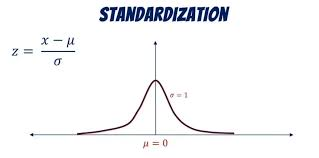


In [7]:
import csv
import numpy as np
import matplotlib.pyplot as plt

In [8]:
with open('/content/covid_africa.csv', 'r') as f:
    reader = csv.reader(f)
    headers = next(reader)
    rows = list(reader)
print(headers)

['Country/Other', 'Total Cases', 'Total Deaths', 'Total Recovered', 'Active Cases', 'Tot Cases/ 1M pop', 'Deaths/ 1M pop', 'Total Tests', 'Tests/ 1M pop', 'Population']


In [9]:
print(rows[0])
print("Total rows:", len(rows))

['Algeria', '271852', '6881', '183061.0', '81910.0', '5995', '152', '230960.0', '5093.0', '45350148']
Total rows: 54


In [10]:
countries = [row[0] for row in rows]
numbers_only = [row[1:] for row in rows]

print(countries[:5])
print(numbers_only[0])

['Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso']
['271852', '6881', '183061.0', '81910.0', '5995', '152', '230960.0', '5093.0', '45350148']


In [11]:
def to_float(val):
    if val.strip() == '':
        return np.nan
    return float(val)

data = np.array([[to_float(v) for v in row] for row in numbers_only])

print(data.shape)
print(data[0])

(54, 9)
[2.7185200e+05 6.8810000e+03 1.8306100e+05 8.1910000e+04 5.9950000e+03
 1.5200000e+02 2.3096000e+05 5.0930000e+03 4.5350148e+07]


In [35]:
# Get column names (exclude the first column which is 'Country/Other')
column_names = headers[1:]

# Loop through each feature column and count how many NaN (missing) values it has
for i in range(data.shape[1]):
    nan_count = np.sum(np.isnan(data[:, i]))
    print(column_names[i], ":", nan_count)

Total Cases : 0
Total Deaths : 0
Total Recovered : 3
Active Cases : 3
Tot Cases/ 1M pop : 0
Deaths/ 1M pop : 0
Total Tests : 3
Tests/ 1M pop : 3
Population : 0


In [36]:
# Make a copy of the data so we don't modify the original
data_clean = data.copy()

# For each column, replace any NaN with that column's mean value
for i in range(data_clean.shape[1]):
    col = data_clean[:, i]
    mean_val = np.nanmean(col)       # Compute mean while ignoring NaNs
    col[np.isnan(col)] = mean_val    # Replace NaNs with the computed mean

# Confirm there are no NaNs left
print("NaNs remaining:", np.isnan(data_clean).sum())

NaNs remaining: 0


In [37]:
# Compute the mean and standard deviation of each column
mean = np.mean(data_clean, axis=0)
std = np.std(data_clean, axis=0)

# Apply z-score standardization: subtract mean, divide by std
# This gives each feature a mean of 0 and standard deviation of 1
standardized_data = (data_clean - mean) / std

print(standardized_data[:5])

[[ 0.07532886  0.14526313 -0.04361689  4.40494752 -0.28846506 -0.30718014
  -0.47365043 -0.75954597  0.51936724]
 [-0.21003692 -0.19557076 -0.18936555 -0.36847384 -0.32943247 -0.49289223
  -0.15918165 -0.5829783   0.24205879]
 [-0.34266751 -0.31758751 -0.32766592 -0.3700479  -0.3406553  -0.57330366
  -0.38111916 -0.56215057 -0.35545959]
 [ 0.17544721 -0.13583699  0.21988802 -0.34661191  1.48538573  1.59780474
  -0.02854414  3.10274358 -0.6333257 ]
 [-0.35288094 -0.30153449 -0.33910555 -0.36654999 -0.35702306 -0.56373087
  -0.46918063 -0.73065861 -0.10514088]]


In [15]:
print("Mean per column:", np.round(np.mean(standardized_data, axis=0), 2))
print("Std per column:", np.round(np.std(standardized_data, axis=0), 2))

Mean per column: [ 0.  0. -0. -0. -0.  0. -0.  0. -0.]
Std per column: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [16]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
standardized_data[:5]  # Display the first few rows of standardized data

array([[ 0.07532886,  0.14526313, -0.04361689,  4.40494752, -0.28846506,
        -0.30718014, -0.47365043, -0.75954597,  0.51936724],
       [-0.21003692, -0.19557076, -0.18936555, -0.36847384, -0.32943247,
        -0.49289223, -0.15918165, -0.5829783 ,  0.24205879],
       [-0.34266751, -0.31758751, -0.32766592, -0.3700479 , -0.3406553 ,
        -0.57330366, -0.38111916, -0.56215057, -0.35545959],
       [ 0.17544721, -0.13583699,  0.21988802, -0.34661191,  1.48538573,
         1.59780474, -0.02854414,  3.10274358, -0.6333257 ],
       [-0.35288094, -0.30153449, -0.33910555, -0.36654999, -0.35702306,
        -0.56373087, -0.46918063, -0.73065861, -0.10514088]])

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [17]:
cov_matrix = np.cov(standardized_data, rowvar=False)

print(cov_matrix.shape)
print(cov_matrix)

(9, 9)
[[ 1.01886792  0.99563389  0.99188965  0.47554039  0.11407379  0.51618861
   0.96751072  0.25931321  0.2335514 ]
 [ 0.99563389  1.01886792  0.96174193  0.53569107  0.09304069  0.50817262
   0.91524655  0.20883333  0.23333338]
 [ 0.99188965  0.96174193  1.01886792  0.46145439  0.08638073  0.39851269
   0.96994967  0.23236287  0.2474435 ]
 [ 0.47554039  0.53569107  0.46145439  1.01886792 -0.04442246  0.10875087
   0.41170131 -0.07058693  0.31937834]
 [ 0.11407379  0.09304069  0.08638073 -0.04442246  1.01886792  0.66789186
   0.11230481  0.34100352 -0.17839911]
 [ 0.51618861  0.50817262  0.39851269  0.10875087  0.66789186  1.01886792
   0.4050237   0.62408757 -0.17574918]
 [ 0.96751072  0.91524655  0.96994967  0.41170131  0.11230481  0.4050237
   1.01886792  0.25976387  0.34381408]
 [ 0.25931321  0.20883333  0.23236287 -0.07058693  0.34100352  0.62408757
   0.25976387  1.01886792 -0.27314237]
 [ 0.2335514   0.23333338  0.2474435   0.31937834 -0.17839911 -0.17574918
   0.34381408 -0

In [18]:
# Step 3: Calculate the Covariance Matrix
cov_matrix

array([[ 1.01886792,  0.99563389,  0.99188965,  0.47554039,  0.11407379,
         0.51618861,  0.96751072,  0.25931321,  0.2335514 ],
       [ 0.99563389,  1.01886792,  0.96174193,  0.53569107,  0.09304069,
         0.50817262,  0.91524655,  0.20883333,  0.23333338],
       [ 0.99188965,  0.96174193,  1.01886792,  0.46145439,  0.08638073,
         0.39851269,  0.96994967,  0.23236287,  0.2474435 ],
       [ 0.47554039,  0.53569107,  0.46145439,  1.01886792, -0.04442246,
         0.10875087,  0.41170131, -0.07058693,  0.31937834],
       [ 0.11407379,  0.09304069,  0.08638073, -0.04442246,  1.01886792,
         0.66789186,  0.11230481,  0.34100352, -0.17839911],
       [ 0.51618861,  0.50817262,  0.39851269,  0.10875087,  0.66789186,
         1.01886792,  0.4050237 ,  0.62408757, -0.17574918],
       [ 0.96751072,  0.91524655,  0.96994967,  0.41170131,  0.11230481,
         0.4050237 ,  1.01886792,  0.25976387,  0.34381408],
       [ 0.25931321,  0.20883333,  0.23236287, -0.07058693,  0

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

1. It reviews relationship between features and whether they change together.

2. It is important because it shows which variables contain similar information, helping us identify redundancy in the data.


### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [19]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:")
print(eigenvalues)
print("\nEigenvectors:", eigenvectors)

Eigenvalues:
[4.64436815 2.11941207 0.83697068 0.67388384 0.56856986 0.24490283
 0.00675082 0.02395363 0.05099943]

Eigenvectors: [[ 0.45886645 -0.0565882  -0.14014516 -0.02490356 -0.13688307  0.08146437
   0.85956897  0.0393377  -0.01410035]
 [ 0.45143868 -0.07892546 -0.10037083  0.07573547 -0.1398117   0.22694854
  -0.28634367 -0.57997441 -0.53361761]
 [ 0.44675534 -0.09650034 -0.17696339 -0.0549254  -0.15705576 -0.23639033
  -0.31482751  0.71674693 -0.25174409]
 [ 0.2484436  -0.26757774  0.3749676   0.76161549  0.34590091 -0.1145516
  -0.0009588   0.03604694  0.10931268]
 [ 0.10753514  0.4948907   0.62964327 -0.06334796 -0.32826779 -0.44688433
   0.06782426 -0.09202971 -0.15006944]
 [ 0.2764197   0.48430358  0.2101885   0.01680426  0.04162441  0.71159797
  -0.14737705  0.21664164  0.260428  ]
 [ 0.44158919 -0.09376038 -0.11346311 -0.2181898  -0.07697047 -0.28467856
  -0.22691756 -0.2916622   0.71568328]
 [ 0.16277121  0.48219086 -0.26917997 -0.10466397  0.74581255 -0.266753
   0.042

In [20]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors

(array([4.64436815, 2.11941207, 0.83697068, 0.67388384, 0.56856986,
        0.24490283, 0.00675082, 0.02395363, 0.05099943]),
 array([[ 0.45886645, -0.0565882 , -0.14014516, -0.02490356, -0.13688307,
          0.08146437,  0.85956897,  0.0393377 , -0.01410035],
        [ 0.45143868, -0.07892546, -0.10037083,  0.07573547, -0.1398117 ,
          0.22694854, -0.28634367, -0.57997441, -0.53361761],
        [ 0.44675534, -0.09650034, -0.17696339, -0.0549254 , -0.15705576,
         -0.23639033, -0.31482751,  0.71674693, -0.25174409],
        [ 0.2484436 , -0.26757774,  0.3749676 ,  0.76161549,  0.34590091,
         -0.1145516 , -0.0009588 ,  0.03604694,  0.10931268],
        [ 0.10753514,  0.4948907 ,  0.62964327, -0.06334796, -0.32826779,
         -0.44688433,  0.06782426, -0.09202971, -0.15006944],
        [ 0.2764197 ,  0.48430358,  0.2101885 ,  0.01680426,  0.04162441,
          0.71159797, -0.14737705,  0.21664164,  0.260428  ],
        [ 0.44158919, -0.09376038, -0.11346311, -0.2181898

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [24]:
sorted_indices = np.argsort(eigenvalues)[::-1]

sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

print("Sorted eigenvalues:")
print(sorted_eigenvalues)

Sorted eigenvalues:
[4.64436815 2.11941207 0.83697068 0.67388384 0.56856986 0.24490283
 0.05099943 0.02395363 0.00675082]


In [25]:
# Step 5: Sort Principal Components
sorted_eigenvectors

array([[ 0.45886645, -0.0565882 , -0.14014516, -0.02490356, -0.13688307,
         0.08146437, -0.01410035,  0.0393377 ,  0.85956897],
       [ 0.45143868, -0.07892546, -0.10037083,  0.07573547, -0.1398117 ,
         0.22694854, -0.53361761, -0.57997441, -0.28634367],
       [ 0.44675534, -0.09650034, -0.17696339, -0.0549254 , -0.15705576,
        -0.23639033, -0.25174409,  0.71674693, -0.31482751],
       [ 0.2484436 , -0.26757774,  0.3749676 ,  0.76161549,  0.34590091,
        -0.1145516 ,  0.10931268,  0.03604694, -0.0009588 ],
       [ 0.10753514,  0.4948907 ,  0.62964327, -0.06334796, -0.32826779,
        -0.44688433, -0.15006944, -0.09202971,  0.06782426],
       [ 0.2764197 ,  0.48430358,  0.2101885 ,  0.01680426,  0.04162441,
         0.71159797,  0.260428  ,  0.21664164, -0.14737705],
       [ 0.44158919, -0.09376038, -0.11346311, -0.2181898 , -0.07697047,
        -0.28467856,  0.71568328, -0.2916622 , -0.22691756],
       [ 0.16277121,  0.48219086, -0.26917997, -0.10466397,  0

In [26]:
total_variance = np.sum(sorted_eigenvalues)
explained_variance_ratio = sorted_eigenvalues / total_variance
cumulative_variance = np.cumsum(explained_variance_ratio)

for i, (var, cum) in enumerate(zip(explained_variance_ratio, cumulative_variance)):
    print(f"PC{i+1}: {var*100:.2f}% (cumulative: {cum*100:.2f}%)")

PC1: 50.65% (cumulative: 50.65%)
PC2: 23.11% (cumulative: 73.76%)
PC3: 9.13% (cumulative: 82.89%)
PC4: 7.35% (cumulative: 90.24%)
PC5: 6.20% (cumulative: 96.44%)
PC6: 2.67% (cumulative: 99.11%)
PC7: 0.56% (cumulative: 99.67%)
PC8: 0.26% (cumulative: 99.93%)
PC9: 0.07% (cumulative: 100.00%)


### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [27]:
num_components = 4

top_eigenvectors = sorted_eigenvectors[:, :num_components]

reduced_data = standardized_data @ top_eigenvectors

print(reduced_data.shape)
print(reduced_data[:5])

(54, 4)
[[ 0.78963441 -2.02927434  1.91736587  3.25609611]
 [-0.66815747 -0.6289371  -0.06529085 -0.3142157 ]
 [-1.03717278 -0.35198796 -0.32682548  0.0841874 ]
 [ 1.0479246   3.35529075 -0.0712379  -0.30302899]
 [-1.07376603 -0.53776246 -0.14596459 -0.02060729]]


In [28]:
# Step 6: Project Data onto Principal Components
num_components = num_components  # Decide on the number of principal components to keep
reduced_data = reduced_data  # Project data onto the principal components
reduced_data[:5]

array([[ 0.78963441, -2.02927434,  1.91736587,  3.25609611],
       [-0.66815747, -0.6289371 , -0.06529085, -0.3142157 ],
       [-1.03717278, -0.35198796, -0.32682548,  0.0841874 ],
       [ 1.0479246 ,  3.35529075, -0.0712379 , -0.30302899],
       [-1.07376603, -0.53776246, -0.14596459, -0.02060729]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [29]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (54, 4)


array([[ 0.78963441, -2.02927434,  1.91736587,  3.25609611],
       [-0.66815747, -0.6289371 , -0.06529085, -0.3142157 ],
       [-1.03717278, -0.35198796, -0.32682548,  0.0841874 ],
       [ 1.0479246 ,  3.35529075, -0.0712379 , -0.30302899],
       [-1.07376603, -0.53776246, -0.14596459, -0.02060729]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

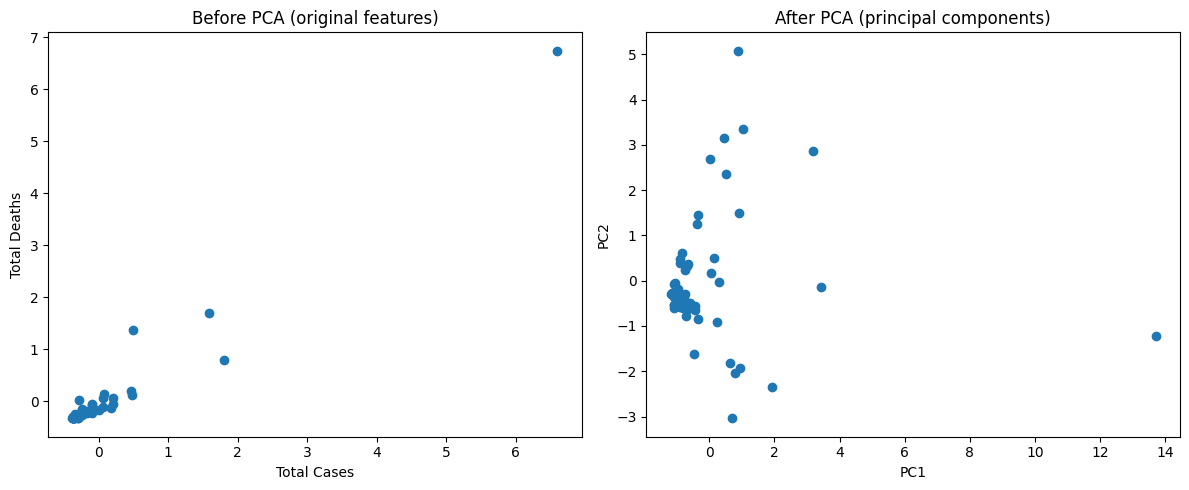

In [34]:
# Step 8: Visualize Before and After PCA

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(standardized_data[:, 0], standardized_data[:, 1])
axes[0].set_xlabel(column_names[0])
axes[0].set_ylabel(column_names[1])
axes[0].set_title("Before PCA (original features)")

axes[1].scatter(reduced_data[:, 0], reduced_data[:, 1])
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("After PCA (principal components)")

plt.tight_layout()
plt.show()


**Visual interpretation**

Before PCA, most countries are crowded close together near the origin, while one extreme country stretches the graph, making it difficult to clearly see differences among the others. After PCA, the data becomes more spread out because PCA combines all 9 features into new components. PC1 explains 50.65% of the variation and PC2 explains 23.11%, making hidden differences between countries easier to notice.

**Why 4 components and tradeoffs was selected**

We selected 4 principal components because together they explain 90.24% of the total variance in the dataset(PC1-PC4) (50.65% + 23.11% + 9.13% + 7.35%). This reduces the data from 9 features to 4 while still keeping most of the important information. The tradeoff is losing about 10% of the smaller details in exchange for a simpler dataset that is easier to analyze.

**Lost information**

The information lost comes from the remaining components (PC5-PC9), which together explain less than 10% of the variance. This mostly represents smaller differences between countries, such as slight variations in testing or population-related factors. However, the main patterns in the data, such as overall COVID impact and country differences, are still preserved.

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?
